In [27]:
from PIL import Image
import io
import base64
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from glob import glob
import time
import json
import requests
from tqdm import tqdm

from torchvision.ops import box_convert

## 1. 工具函数

In [6]:
def xyxy_to_xywh(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]
    
    w = x2 - x1
    h = y2 - y1
    return [x1, y1, w, h]

def xyxy_get_area(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]

    w = x2 - x1
    h = y2 - y1
    return w*h

def image_to_base64(img_path):
    img = Image.open(img_path)
    w, h = img.size
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    img_bytes = buffered.getvalue()
    
    img_base64 = base64.b64encode(img_bytes).decode("utf-8")
    
    img_base64_str = f"data:image/png;base64,{img_base64}"
    return img_base64_str, [w, h]

def show_img(img, bboxes = None, tag = None, captions = None):
    '''
        Function: used to show image and corresponding bounding boxes.
    '''
    fig, ax = plt.subplots()
    
    ax.imshow(img)
    
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            if tag is not None:
                ax.text(x, y-8, str(i+1), color='r', fontsize=11, weight='bold')
            if captions is not None:
                ax.text(x+20, y-8, captions[i], color='r', fontsize=11, weight='bold')
    plt.axis("off")
    plt.show()

In [155]:
def create_dino_task(token, img_base64, caption, bbox_threshold = 0.4, iou_threshold = 0.8):
    headers = {
        "Content-Type": "application/json",
        "Token": token
    }
    
    json_data = {
        "model": "GroundingDino-1.5-Pro",
        "image": img_base64,
        "prompt": {
            "type": "text",
            "text": caption
        },
        "targets": ["bbox"],
        "bbox_threshold": bbox_threshold,
        "iou_threshold": iou_threshold
    }
    
    start_time = time.time()
    results = requests.post(
        url = "https://api.deepdataspace.com/v2/task/grounding_dino/detection",
        headers = headers,
        json = json_data,
    ).json()

    # print("Status Code:", response.status_code)
    # print("Raw Response Text:", response.text)

    return results["data"]["task_uuid"], start_time

In [52]:
def get_status(token, task_uuid, start_time):
    headers = {
        "Content-Type": "application/json",
        "Token": token
    }
    
    while True:
        response = requests.get(
            url = f'https://api.deepdataspace.com/v2/task_status/{task_uuid}', 
            headers = headers
        ).json()
        if response["data"]["status"] not in ["waiting", "running"]:
            break
        time.sleep(1)

    if response["data"]["status"] == "failed":
        return None
    elif response["data"]["status"] == "success":
        inference_time = time.time() - start_time
        outcomes = response["data"]["result"]["objects"]
        result = []
        for o in outcomes:
            result.append({
                "bbox":xyxy_to_xywh(np.array(o["bbox"]).astype(np.int64).tolist()),
                "area":xyxy_get_area(o["bbox"]),
                "label":o["category"],
                "score":o["score"]
            })
        return result, inference_time

## 2. Dino1.5模型推断

In [174]:
token = "fc4e77f965748aec14c524174f38000b"

path_list = [
    # "./imgs/dataset/1. gas cylinder/*.jpg",
    # "./imgs/dataset/2. working at height/*.jpg",
    # "./imgs/dataset/3. worker with hardhat & vest/*.jpg",
    "./imgs/dataset/4. working with eye protection/*.jpg",
    "./imgs/dataset/5. vehicle/*.jpg",
]
# dino是对单复数敏感的。cylinder 只会获取一个bbox；cylinders 会获取所有的bbox.
caption_list = [
    # "gas cylinders.",
    # "workers",
    # "workers",
    "workers",
    "excavators"
]

In [175]:
for j in range(len(path_list)):
    img_path_list = glob(path_list[j])
    print(f"The quantity of images: {len(img_path_list)}")
    caption = caption_list[j]

    img_outcome = {}
    for i, img_path in tqdm(enumerate(img_path_list), total = len(img_path_list)):
        img_base64, image_size = image_to_base64(img_path)
        task_uuid, start_time = create_dino_task(
            token = token, 
            img_base64 = img_base64,
            caption = caption,
            bbox_threshold = 0.35, 
            iou_threshold = 0.25
        )
        
        outcome, inference_time = get_status(
            token = token, 
            task_uuid = task_uuid, 
            start_time = start_time
        )
    
        img_outcome[i] = {
            "img_path":img_path,
            "img_size":image_size, #[width, height]
            "inference_time":inference_time,
            "result":outcome
        }
        time.sleep(1)
    with open(f"./results/dino15_{j+4}.json", "w") as fp:
        fp.write(json.dumps(img_outcome))

The quantity of images: 409


100%|██████████████████████████████████████████████████████████████████████████████| 409/409 [1:08:28<00:00, 10.05s/it]


The quantity of images: 837


100%|██████████████████████████████████████████████████████████████████████████████| 837/837 [3:26:31<00:00, 14.80s/it]


In [26]:
img_path_list = glob("./imgs/*.jpg")
img_outcome = {}
for i, img_path in enumerate(img_path_list):
    img_base64, image_size = image_to_base64(img_path)
    task_uuid, start_time = create_dino_task(
        token = token, 
        img_base64 = img_base64,
        caption = caption,
        bbox_threshold = 0.4, 
        iou_threshold = 0.8
    )
    
    outcome, inference_time = get_status(
        token = token, 
        task_uuid = task_uuid, 
        start_time = start_time
    )

    img_outcome[i] = {
        "img_path":img_path,
        "img_size":image_size, #[width, height]
        "inference_time":inference_time,
        "result":outcome
    }

In [27]:
with open(f"./results/dino15_{1}.json", "w") as fp:
    fp.write(json.dumps(img_outcome))

In [135]:
img_path = "./imgs/dataset/1. gas cylinder/1_128.jpg"
img = Image.open(img_path)
img_base64, image_size = image_to_base64(img_path)

caption = "gas tanks." 

task_uuid, start_time = create_dino_task(
    token = token, 
    img_base64 = img_base64, 
    caption = caption,
    bbox_threshold = 0.35, 
    iou_threshold = 0.25
)
outcome, inference_time = get_status(
    token = token, 
    task_uuid = task_uuid, 
    start_time = start_time
)
print(outcome)

[{'bbox': [177, 96, 102, 100], 'area': 10284.680935946759, 'label': 'gas tanks', 'score': 0.5351581573486328}, {'bbox': [112, 160, 117, 97], 'area': 11412.435062133707, 'label': 'gas tanks', 'score': 0.40532106161117554}, {'bbox': [323, 93, 55, 33], 'area': 1794.4826140720397, 'label': 'gas tanks', 'score': 0.3594300448894501}]


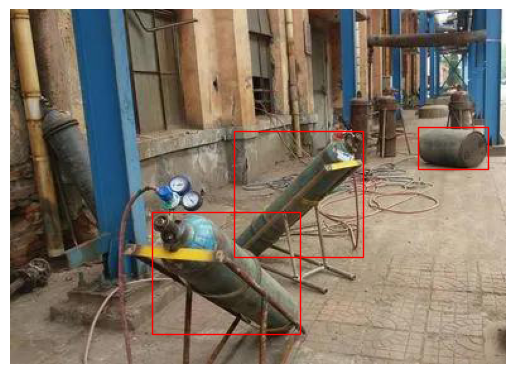

In [136]:
bboxes = [item["bbox"] for item in outcome]
show_img(img, bboxes)

In [ ]:
# img_path = "./imgs/dataset/5. vehicle/5_2_3.jpg"
# img = Image.open(img_path).convert("RGB")
# caption = [["excavators"]]

# outcome, image_size, inference_time = owlv2_processor(
#     model=model, 
#     processor=processor, 
#     img = img, 
#     caption=caption
# )

# print(outcome)
# bboxes = [item["bbox"] for item in outcome ]
# show_img(img, bboxes)